# NGUYỄN QUỐC TRỌNG - 2413682

# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "NGUYỄN QUỐC TRỌNG"  # TODO: Họ và tên
STUDENT_ID = "2413682"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: NGUYỄN QUỐC TRỌNG (2413682)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\#BT_AI\Homework\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
max_logits = np.max(logits, axis=1, keepdims=True)
shifted_logits = logits - max_logits
exp_logits = np.exp(shifted_logits)
sum_exp_logits = np.sum(exp_logits, axis=1, keepdims=True)
class_probabilities = exp_logits / sum_exp_logits
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)
print(class_probabilities)
print(predicted_classes)

[[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]]
[0 1 2 0]


In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
correct_mask = (predicted_classes == true_labels)
high_confidence_mask = (confidence_scores >= confidence_threshold)
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0]
print(review_indices)

[0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = normalized_batch[:, :, ::-1, :].copy()
augmented_batch[0, 0, 0, 0] = 1.0
print(augmented_batch.shape)
print(augmented_batch[0, 0, 0, 0])

(2, 4, 4, 3)
1.0


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

1. Mỗi dòng đại diện cho một mẫu xe trong bộ dữ liệu 1985 Auto Imports.
2. Giá trị thiếu được giữ dưới dạng ký hiệu dấu chấm hỏi: ?
3. Cột này thể hiện Mức đánh giá rủi ro bảo hiểm của xe

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()
# print(raw_df.head())
print(raw_missing_marker_count)

59


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isna().sum()
# print(missing_by_column)
print(df_clean.dtypes)

symboling              int64
normalized_losses    float64
make                     str
fuel_type                str
aspiration               str
num_doors                str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_cylinders            str
engine_size            int64
fuel_system              str
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                float64
dtype: object


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

+ Các cột numeric đại diện cho các đại lượng có đơn vị, thang đo và ý nghĩa hoàn toàn khác nhau. Việc điền cùng một giá trị hằng số sẽ làm ảnh hưởng đến phân phối thống kê của từng đặc trưng và phá vỡ mối quan hệ giữa chúng, dẫn đến mô hình học máy học sai quy luật.
+ Nên drop các dòng thiếu price. Biến price đóng vai trò là biến mục tiêu. Việc fill biến mục tiêu bằng các kỹ thuật như mean/median sẽ làm nhiễu dữ liệu đánh giá hoặc huấn luyện.
+ Cột normalized_losses bị thiếu tới 41 giá trị. Nếu áp dụng phương pháp drop dòng chứa NaN cho cột này, ta sẽ mất đi một lượng lớn các quan sát hợp lệ ở các cột khác, gây lãng phí dữ liệu trầm trọng. Ngược lại, nếu chọn cách fill, do lượng thiếu quá lớn, phương pháp điền sẽ áp đặt một độ chệch đáng kể lên cột này, làm giảm độ tin cậy của đặc trưng normalized_losses trong các mô hình.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std
print(analysis_df.shape)
print(X_auto_scaled.mean(axis=0))

(199, 6)
[ 9.81905791e-17  4.24004773e-17  9.81905791e-17 -8.92641628e-18
  2.23160407e-16 -1.07116995e-16]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[:, price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = X_auto[price_outlier_mask, price_index]
print(price_outliers)

[30760. 41315. 36880. 32250. 35550. 36000. 31600. 34184. 35056. 40960.
 45400. 32528. 34028. 37028.]


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
engine_index = AUTO_FEATURES.index('engine_size')
engine_array = X_auto[:, engine_index]
price_array = X_auto[:, price_index]
engine_price_corr = np.corrcoef(engine_array, price_array)[0, 1]
price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()
print(engine_price_corr)

0.8738869517981515


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

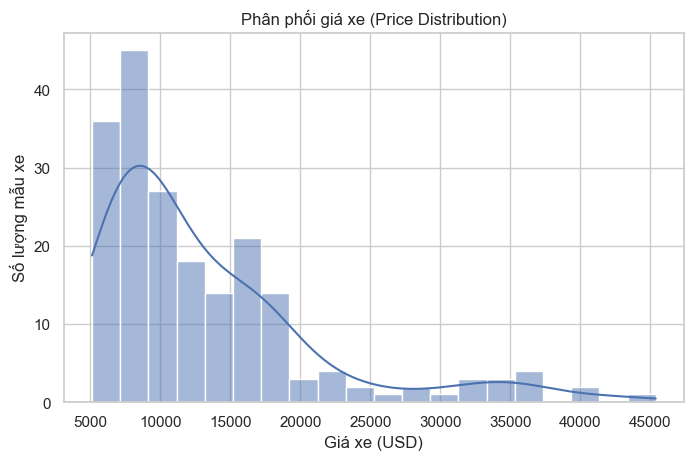

In [20]:
# TODO M2.1: histogram/KDE của price
plt.figure()
sns.histplot(data=df_clean, x='price', kde=True, bins=20)
plt.title("Phân phối giá xe (Price Distribution)")
plt.xlabel("Giá xe (USD)")
plt.ylabel("Số lượng mẫu xe")
plt.show()

**Nhận xét:** Giá xe có phân phối lệch phải, tập trung chủ yếu ở phân khúc giá bình dân từ 5,000 đến 15,000 USD. Tần suất giảm dần khi giá tăng lên, xuất hiện một vài mẫu xe thuộc phân khúc cao cấp có giá vượt ngưỡng 30,000 USD(hay có thể coi là outliers).

## M2.2 Dataset có cân bằng theo body style không?

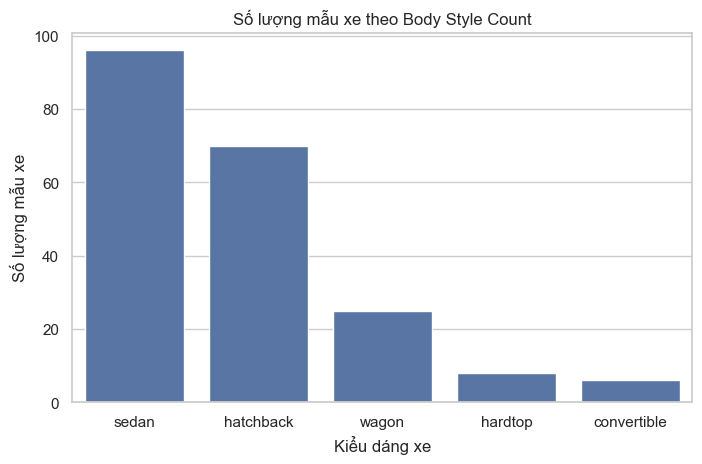

In [21]:
# TODO M2.2: countplot của body_style
plt.figure()

order = df_clean['body_style'].value_counts().index
sns.countplot(data=df_clean, x='body_style', order=order)
plt.title("Số lượng mẫu xe theo Body Style Count")
plt.xlabel("Kiểu dáng xe")
plt.ylabel("Số lượng mẫu xe")
plt.show()

**Nhận xét:** Tập dữ liệu mất cân bằng khá rõ rệt theo kiểu dáng xe. Các dòng xe phổ thông như sedan và hatchback chiếm đa số áp đảo, trong khi các dòng xe đặc thù như convertible và hardtop có số lượng rất khiêm tốn.

## M2.3 Price khác nhau theo body style ra sao?

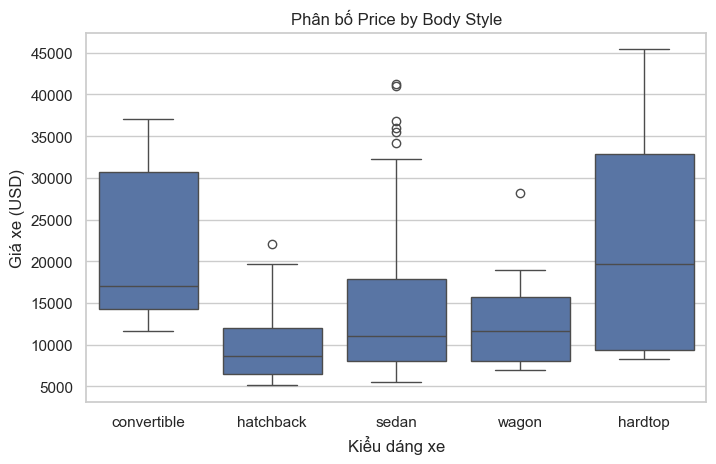

In [22]:
# TODO M2.3: boxplot price theo body_style
plt.figure()
sns.boxplot(data=df_clean, x='body_style', y='price')
plt.title("Phân bố Price by Body Style")
plt.xlabel("Kiểu dáng xe")
plt.ylabel("Giá xe (USD)")
plt.show()

**Nhận xét:** Dòng xe hardtop và convertible có mức giá trung bình cao nhất và dải biến động giá rộng. Ngược lại, dòng hatchback nhắm tới phân khúc giá rẻ nhất với mức giá phân bố khá tập trung và ít biến động. Dòng se Sedan có xuất hiện outlier khá nhiều so với các hãng xe còn lại.

## M2.4 Engine size liên quan thế nào tới price?

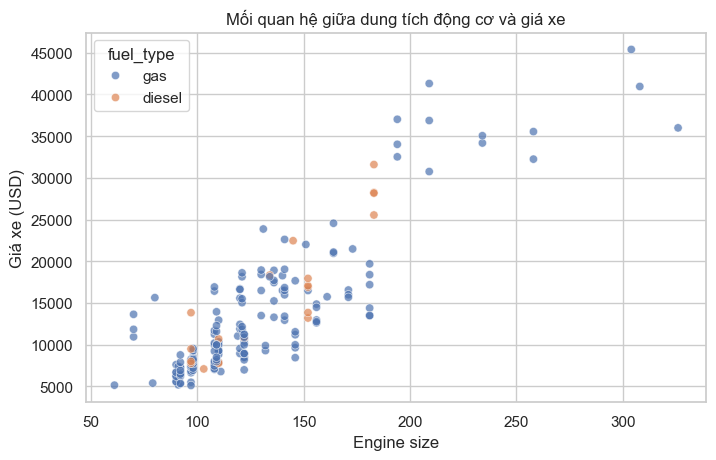

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure()
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', alpha=0.7)
plt.title("Mối quan hệ giữa dung tích động cơ và giá xe")
plt.xlabel("Engine size")
plt.ylabel("Giá xe (USD)")
plt.show()

**Nhận xét:** Động cơ càng lớn thì giá xe càng cao. Xe sử dụng nhiên liệu xăng (gas) bao phủ toàn bộ dải giá và dung tích, trong khi xe dầu (diesel) thường chỉ tập trung ở phân khúc dung tích và giá tiền tầm trung.

## M2.5 Các feature numeric tương quan ra sao?

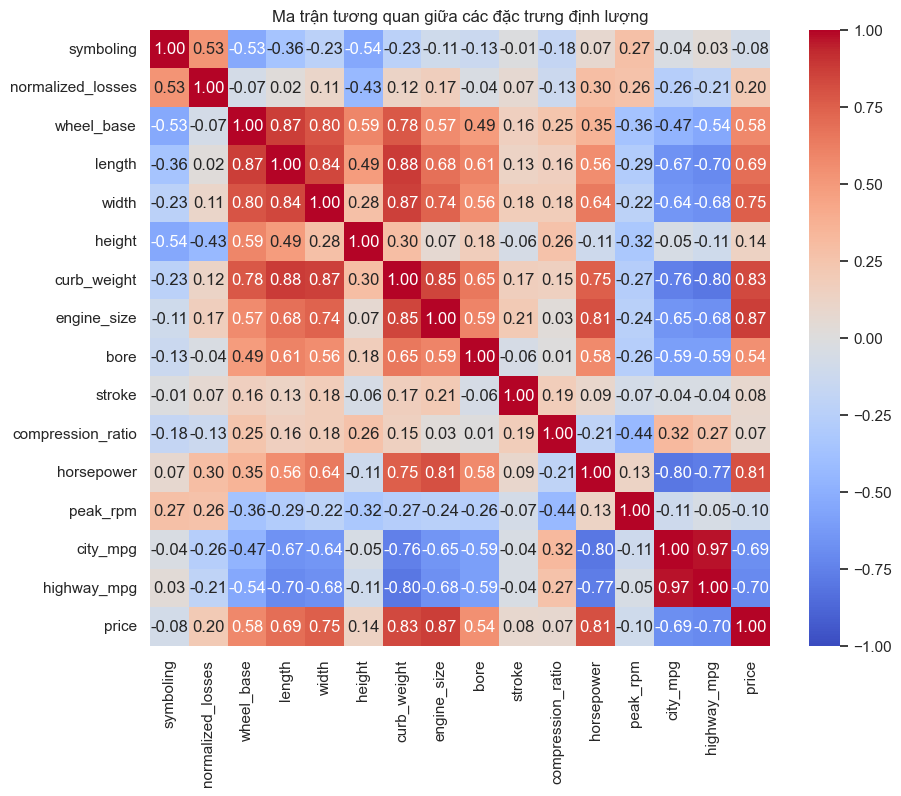

In [24]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(10, 8)) # Tăng kích thước để dễ đọc số

corr_matrix = df_clean[NUMERIC_COLUMNS].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Ma trận tương quan giữa các đặc trưng định lượng")
plt.show()

**Nhận xét:** Đặc trưng price có tương quan thuận cực kỳ mạnh với engine size, curb weight, horsepower (giá trị > 0.8) và tương quan nghịch mạnh với các chỉ số tiết kiệm nhiên liệu như city mpg, highway mpg. Điều này hợp lý với thực tế: xe càng nặng, máy càng khỏe thì càng đắt tiền nhưng lại hao xăng hơn.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

### Mã lực (horsepower) ảnh hưởng thế nào đến mức tiết kiệm nhiên liệu trên đường cao tốc (highway_mpg)?

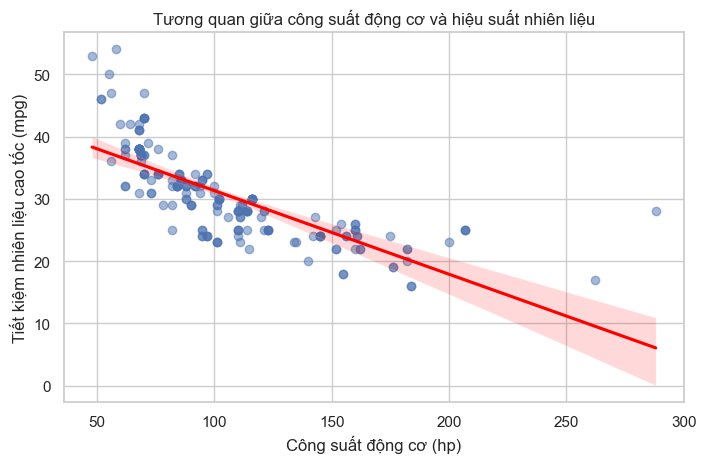

In [25]:
# TODO M2.6: biểu đồ tự chọn
plt.figure()
sns.regplot(data=df_clean, x='horsepower', y='highway_mpg', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Tương quan giữa công suất động cơ và hiệu suất nhiên liệu")
plt.xlabel("Công suất động cơ (hp)")
plt.ylabel("Tiết kiệm nhiên liệu cao tốc (mpg)")
plt.show()

**Nhận xét:** Có một mối tương quan nghịch rõ rệt giữa công suất động cơ và mức độ tiết kiệm nhiên liệu. Những mẫu xe sở hữu mã lực lớn (từ 150 hp trở lên) tiêu tốn nhiều nhiên liệu hơn hẳn trên đường cao tốc so với các dòng xe phổ thông công suất thấp.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

1. Phát hiện chính có dẫn chứng
+ price có tương quan thuận cực mạnh (> 0.8) với engine_size, curb_weight, và horsepower.

+ horsepower có tương quan nghịch rõ rệt với mức tiết kiệm nhiên liệu (city_mpg, highway_mpg).

+ Biểu đồ countplot cho thấy sedan và hatchback chiếm áp đảo số lượng.

+ Boxplot chỉ ra hardtop và convertible có giá trung bình cao nhất; hatchback có dải giá thấp nhất.

2. Hạn chế của Dataset
+ Dữ liệu khuyết thiếu nhiều: Cột normalized_losses bị thiếu tới 20% dữ liệu, gây khó khăn cho việc xử lý (xóa hay điền đều làm nhiễu).

+ Dữ liệu lỗi thời: Thu thập từ năm 1985, không còn phản ánh đúng công nghệ (xe điện, an toàn) và mặt bằng giá cả hiện tại.

3. Ví dụ: Correlation không đồng nghĩa Causation
+ Trọng lượng (curb_weight) và Giá xe (price): Hai biến này có tương quan thuận, nhưng bạn không thể làm một chiếc xe đắt lên bằng cách chất thêm tạ vào cho nặng. Nguyên nhân thực sự là các xe đắt tiền thường lắp động cơ to và khung gầm vật liệu cao cấp nên mới nặng hơn.

4. Câu hỏi phân tích tiếp
+ Nếu giữ nguyên toàn bộ thông số kỹ thuật (mã lực, trọng lượng, mức hao xăng), liệu thương hiệu (make) có làm thay đổi giá bán một cách đáng kể hay không?